## Índice

- [0. Configuración del entorno](#0.-Configuración-del-entorno)
- [1. Limpieza de datos](#1.-Limpieza-de-datos)
- [2. Clusterización](#2.-Clusterización)
  - [2.1. Clusterización en el dataset CIBERESUCICOVID](#2.1.-Clusterización-en-el-dataset-CIBERESUCICOVID)
  - [2.2 Clusterización en todos los datasets](#2.2-Clusterización-en-todos-los-datasets)

## 0. Configuración del entorno

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, limpieza, privacidad

cfg = carga.cargar_config()
N_MIN = cfg["privacidad"]["n_minimo_celda"]
REG = list(cfg["registros"])
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida",
       "TENACITY": "TENACITY", "VIRGEN_DEL_ROCIO": "Virgen del Rocío"}
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 110)


def nota(ax, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    ax.figure.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")

## 1. Limpieza de datos

La limpieza de datos se ha centrado en la aplicación de 14 reglas para obtener tablas coherentes, trazables y comparables entre cohortes. Cada modificación queda registrada y las medidas descartadas se conservan identificadas con su motivo de exclusión
| Regla | Aplicación | Justificación |
|---|---|---|
| R01. Códigos desconocidos | Convertir los códigos de desconocimiento 9, 9999 y 99999, cuando corresponda y el sexo no especificado en valores ausentes. | Evitar que se interpreten como valores reales o categorías clínicas. |
| R02. Edad | Representar los tramos de edad mediante un orden y grupos amplios; dejar sin grupo los intervalos que cruzan categorías. | Respetar la información disponible sin inventar una edad exacta ni asignar grupos ambiguos. |
| R03. Fechas | Interpretar las fechas con el formato específico de cada registro y calcular los días entre el alta y la prueba. | Situar las medidas en un eje temporal comparable y evitar errores de formato. |
| R04. Pruebas anteriores al alta | Excluir del análisis temporal las medidas fechadas antes del alta. | Evitar que datos del episodio agudo se interpreten como seguimiento posterior. |
| R05. Rangos plausibles | Marcar como excluidas las medidas fuera de los rangos establecidos en la configuración. | Reducir el efecto de posibles errores de registro o unidades, sin eliminar silenciosamente los valores. |
| R06. Pruebas duplicadas | En pacientes compartidos, conservar la prueba del registro socio cuando exista una duplicación. | Evitar contar dos veces una misma medida y mantener una regla de prioridad consistente. |
| R07. Cohorte de análisis | Asignar cada paciente a un único lado de la comparación entre cohortes. | Evitar que una misma persona participe en descubrimiento y replicación, comprometiendo su independencia. |
| R08. Supervivencia e inconsistencias | Identificar la supervivencia al alta y marcar como inconsistentes los casos con fallecimiento hospitalario y seguimiento posterior. | Detectar contradicciones que impiden interpretar correctamente la trayectoria. |
| R09. Cumplimentación | En CIBERESUCICOVID, exigir `IH_PorcCMD ≥ 50` y evaluar `≥ 99` como análisis de sensibilidad. | Establecer un mínimo de información y comprobar si los resultados cambian con un criterio más exigente. |
| R10. TAC y fibrosis | Utilizar formularios completos o con TAC realizado y distinguir las definiciones estricta y amplia de fibrosis. | No confundir formularios sin cumplimentar con ausencia de lesiones y hacer explícita la definición utilizada. |
| R11. Tipos de ausencia | Diferenciar una variable no recogida por la cohort (`no_recogida`) de una medida que falta (`falta`). | Evitar imputaciones injustificadas y distinguir diferencias de diseño de pérdidas de información. |
| R12. Seguimiento en TENACITY | Separar el abandono de seguimiento de las visitas que todavía no correspondía realizar. | No contabilizar como pérdida una visita que aún no debía estar disponible. |
| R13. Ventana de definición | Construir el estado clínico entre 60 y 210 días y las banderas de inclusión de las capas A y B. | Aplicar criterios temporales y de elegibilidad explícitos y reproducibles. |
| R14. Preguntas condicionadas | En CIBERESUCICOVID, deducir `fatiga = 0` cuando la resolución clínica es total y la pregunta está condicionada. | Evitar que un salto del cuestionario se trate como una ausencia ordinaria; el valor debe identificarse como deducido, no como respuesta observada. |

In [ ]:
tablas = limpieza.limpiar(cfg)
pacientes, medidas, estado = tablas["pacientes"], tablas["medidas"], tablas["estado_definicion"]
for nombre, t in tablas.items():
    print(f"{nombre:<20} {t.shape[0]:>7,} filas × {t.shape[1]:>3} columnas")

In [ ]:
reg = tablas["registro_limpieza"].copy()
reg.columns = [ETQ.get(c.removeprefix("N_"), c) for c in reg.columns]
cols_n = ["N", *[ETQ[r] for r in REG if ETQ[r] in reg.columns]]
reg = privacidad.suprimir_celdas(reg, N_MIN, cols_n)
reg.to_csv(TAB / "02_registro_limpieza.csv", index=False)
reg.set_index(["regla", "tabla"])

Tras aplicar las reglas de limpieza, la base original se reorganizó en seis tablas complementarias. Esta estructura separa la información individual de las mediciones longitudinales y de los registros de auditoría, facilitando el análisis temporal y la trazabilidad de las decisiones. Las medidas descartadas no se eliminan silenciosamente, sino que se conservan identificadas con su motivo de exclusión:
| Tabla             | Contenido y organización                                                                                                                               | Utilidad                                                                                       |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- |
| pacientes         | Información a nivel de paciente, con variables individuales, cohort de análisis y banderas de calidad y elegibilidad.                                  | Seleccionar la población que puede participar en cada análisis.                                |
| medidas           | Mediciones de seguimiento en formato longitudinal, incluyendo información temporal y marcas de exclusión. Un paciente puede tener múltiples registros. | Recuperar las medidas válidas y construir las variables de cada horizonte.                     |
| estado_definicion | Estado clínico construido en la ventana de definición de 60–210 días.                                                                                  | Disponer de una representación del paciente para los análisis de las capas A y B.              |
| visitas_tenacity  | Información por paciente y visita de TENACITY, diferenciando los estados del seguimiento.                                                              | Separar visitas no realizadas, pérdidas de seguimiento y visitas que todavía no correspondían. |
| registro_limpieza | Reglas aplicadas, tabla afectada, descripción y recuentos por registro.                                                                                | Auditar qué se ha modificado y cuántos casos se han visto afectados.                           |
| flujo_consort     | Recuentos del proceso de selección de la muestra.                                                                                                      | Documentar cómo se pasa de la población inicial a la población analizable.                     |

In [2]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

# Localizar el proyecto desde la raíz o un subdirectorio.
RAIZ = next(
    (
        carpeta
        for carpeta in [Path.cwd(), *Path.cwd().parents]
        if (carpeta / "src" / "limpieza.py").exists()
    ),
    None,
)

if RAIZ is None:
    raise FileNotFoundError(
        "No se encuentra src/limpieza.py. "
        "Ejecuta el notebook dentro del proyecto."
    )

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src import carga, limpieza

# Aplicar las reglas implementadas en el proyecto.
cfg = carga.cargar_config()
tablas = limpieza.limpiar(cfg)

nombres = [
    "pacientes",
    "medidas",
    "estado_definicion",
    "visitas_tenacity",
    "registro_limpieza",
    "flujo_consort",
]

faltantes = set(nombres) - set(tablas)
if faltantes:
    raise KeyError(f"Faltan tablas de salida: {sorted(faltantes)}")

# Dejar las seis tablas disponibles para las siguientes secciones.
pacientes = tablas["pacientes"]
medidas = tablas["medidas"]
estado = tablas["estado_definicion"]
visitas_tenacity = tablas["visitas_tenacity"]
registro_limpieza = tablas["registro_limpieza"]
flujo_consort = tablas["flujo_consort"]

# Guardar mediante la función existente y la ruta configurada.
carpeta_procesados = Path(limpieza.guardar(tablas, cfg))

# Mostrar únicamente dimensiones, no registros individuales.
resumen_tablas = pd.DataFrame(
    [
        {
            "Tabla": nombre,
            "Filas": len(tablas[nombre]),
            "Columnas": tablas[nombre].shape[1],
            "Archivo guardado": (
                carpeta_procesados / f"{nombre}.parquet"
            ).exists(),
        }
        for nombre in nombres
    ]
).set_index("Tabla")

display(resumen_tablas)

,Filas,Columnas,Archivo guardado
Tabla,,,
pacientes,9809,53,True
medidas,86810,14,True
estado_definicion,9809,38,True
visitas_tenacity,861,4,True
registro_limpieza,33,8,True
flujo_consort,7,5,True


## 2. Clusterización

### 2.1. Clusterización en el dataset CIBERESUCICOVID

La idea es identificar fenotipos de pacientes en CIBERESUCICOVID a partir de su función pulmonar y sus síntomas durante el seguimiento, y caracterizar las diferencias clínicas y demográficas entre los grupos obtenidos. Para ello, se realizan tres análisis de clustering con la información disponible hasta los 3, 6 y 12 meses, utilizando la distancia de Gower y el algoritmo PAM. Las variables demográficas, la gravedad y las comorbilidades se emplean para describir los fenotipos, pero no intervienen en su definición. Posteriormente, se evalúa la posibilidad de transferir estos grupos a pacientes de POSTCOVID-Lleida mediante las variables comparables entre cohortes, DLCO y FVC. El objetivo final es estudiar si la pertenencia a un fenotipo temprano se relaciona con la evolución a largo plazo, aunque la asignación a un grupo no constituye por sí sola una predicción validada de las secuelas futuras.

Preparación de variables


In [3]:
from IPython.display import display
from sklearn.metrics import adjusted_rand_score
from src import fenotipado as F, pasaporte as P

FC = cfg["fenotipado"]
DESC = FC["descubre"]
SEMILLA = cfg["semilla"]

HORIZONTES = ["H3", "H6", "H12"]
KS = list(range(FC["k_rango"][0], FC["k_rango"][1] + 1))
COHORTES = list(dict.fromkeys([DESC, *FC["replica"]]))

assert DESC == "CIBERESUCICOVID", (
    f"La configuración descubre en {DESC}, no en CIBERESUCICOVID."
)
assert all(h in FC["horizontes"] for h in HORIZONTES)

FIG = RAIZ / cfg["rutas"]["figuras"]
TAB = RAIZ / cfg["rutas"]["tablas"]
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)


def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", dpi=150)


def nombre_f(c):
    return f"F{int(c) + 1}"


tablas_var = {
    (h, cohorte): F.construir_variables(
        medidas, pacientes, cfg, h, cohorte
    )
    for h in HORIZONTES
    for cohorte in COHORTES
}

auditoria = []

for h in HORIZONTES:
    t, cols = tablas_var[(h, DESC)]
    ultima_visita = FC["horizontes"][h][-1]
    limite = FC["visitas"][ultima_visita]["ventana"][1]

    if t.empty:
        raise ValueError(f"No hay pacientes elegibles para {h}.")

    assert t.index.is_unique, f"Índices de paciente duplicados en {h}."
    assert t["dias_max"].max() <= limite, (
        f"Hay medidas posteriores a la ventana permitida en {h}."
    )

    auditoria.append({
        "Horizonte": h,
        "Visitas utilizadas": " + ".join(FC["horizontes"][h]),
        "N": len(t),
        "Variables de clustering": ", ".join(cols),
        "Límite de ventana (días)": limite,
        "Máximo día utilizado": t["dias_max"].max(),
    })

auditoria = pd.DataFrame(auditoria).set_index("Horizonte")
display(privacidad.suprimir_celdas(auditoria, N_MIN, ["N"]))

cobertura = pd.concat({
    h: tablas_var[(h, DESC)][0][tablas_var[(h, DESC)][1]]
        .notna().mean().mul(100)
    for h in HORIZONTES
}, axis=1).round(1)

print("Cobertura de las variables de clustering (% con dato):")
display(cobertura)

print("Dominios y variables definidos en la configuración:")
display(pd.Series(FC["dominios"], name="Variables"))

,Visitas utilizadas,N,Variables de clustering,Límite de ventana (días),Máximo día utilizado
Horizonte,,,,,
H3,M3,913,"dlco_M3, fvc_M3, fatiga_M3, resolucion_M3",150,150.0
H6,M3 + M6,799,"dlco_M3, dlco_M6, dlco_cambio, fvc_M3, fvc_M6, fvc_cambio, fatiga_M3, fatiga_M6, resolucion_M3, resolucion_M6",270,270.0
H12,M3 + M6 + A1,566,"dlco_M3, dlco_M6, dlco_A1, dlco_cambio, fvc_M3, fvc_M6, fvc_A1, fvc_cambio, fatiga_M3, fatiga_M6, resoluci...",480,479.0


Cobertura de las variables de clustering (% con dato):


,H3,H6,H12
dlco_M3,81.4,32.2,37.5
fvc_M3,98.5,37.5,45.6
fatiga_M3,99.9,88.4,85.7
resolucion_M3,100.0,88.9,86.0
dlco_M6,NaN,80.1,39.9
dlco_cambio,NaN,29.3,54.9
fvc_M6,NaN,98.2,47.0
fvc_cambio,NaN,37.2,68.7
fatiga_M6,NaN,99.5,86.9
resolucion_M6,NaN,100.0,87.3


Dominios y variables definidos en la configuración:


funcion              [dlco, fvc]
sintomas    [fatiga, resolucion]
Name: Variables, dtype: object

Ejecución del clústering

In [4]:
def ejecutar_clustering(h, replicar=True):
    t, cols = tablas_var[(h, DESC)]
    t = t.loc[t[cols].notna().any(axis=1)].copy()

    if len(t) <= max(KS):
        raise ValueError(
            f"{h}: N={len(t)} insuficiente para evaluar k hasta {max(KS)}."
        )

    X = t[cols].to_numpy(dtype=float)
    R, w, cat = F.parametros_gower(cols, cfg)

    D = F.gower(X, None, R, w, cat)

    if not np.isfinite(D).all():
        raise ValueError(
            f"{h}: hay distancias no finitas. Revisa cobertura y "
            "pares de pacientes sin variables comparables."
        )

    nulo = F.seleccion_k_nulo(
        X, R, w, cat, KS,
        FC["n_permutaciones"], SEMILLA, D
    )

    k, estructura = F.elegir_k(nulo)
    lab, med = F.pam(D, k, SEMILLA)

    ultima = FC["horizontes"][h][-1]
    ref = t[f"dlco_{ultima}"].to_numpy(dtype=float)
    lab, med = F.ordenar_por_dlco(lab, med, ref)

    r = {
        "h": h,
        "desc": t,
        "cols": cols,
        "X": X,
        "D": D,
        "R": R,
        "w": w,
        "cat": cat,
        "nulo": nulo,
        "k": k,
        "estructura": estructura,
        "lab": lab,
        "med": med,
        "silueta": F.silueta(D, lab),
        "estab": F.estabilidad_bootstrap(
            D, lab, k, FC["n_bootstrap"], SEMILLA
        ),
        "centros": F.estabilidad_centros(
            D, lab, t["centro_id"], k,
            FC["min_pacientes_centro"], SEMILLA
        ),
        "replicas": {},
    }

    solo_comp = np.array([
        c.rsplit("_", 1)[0] in FC["compartidas"]
        for c in cols
    ])

    # Comparar etiquetas originales con asignación solo respiratoria.
    X_comp = np.where(solo_comp, X, np.nan)
    evaluables = np.isfinite(X_comp).any(axis=1)

    r["n_solo_compartidas"] = int(evaluables.sum())
    r["ari_solo_compartidas"] = np.nan

    if evaluables.sum() >= 2:
        D_comp = F.gower(
            X_comp[evaluables], X[med], R, w, cat
        )
        if np.isfinite(D_comp).all():
            lab_comp = F.asignar_medoides(D_comp)
            r["ari_solo_compartidas"] = adjusted_rand_score(
                lab[evaluables], lab_comp
            )

    if replicar:
        for cohorte in FC["replica"]:
            tr = tablas_var[(h, cohorte)][0].copy()
            X_rep = tr.reindex(columns=cols).to_numpy(dtype=float)

            # Evitar asignar pacientes sin ninguna variable compartida.
            validos = np.isfinite(X_rep[:, solo_comp]).any(axis=1)
            tr = tr.loc[validos]
            X_rep = X_rep[validos]

            if len(tr) < 2 * k:
                continue

            out = P.replicar(
                X, med, X_rep, R, w, cat, k,
                FC["n_bootstrap"], SEMILLA
            )
            out["datos"] = tr
            r["replicas"][cohorte] = out

    return r


resultados = {
    h: ejecutar_clustering(h, replicar=True)
    for h in HORIZONTES
}

resumen = pd.DataFrame([
    {
        "Horizonte": h,
        "N": len(r["desc"]),
        "k": r["k"],
        "Estructura frente al nulo": bool(r["estructura"]),
        "Silueta": r["silueta"],
        "Jaccard bootstrap mínimo": r["estab"]["jaccard_medio"].min(),
        "ARI entre centros (mediana)": (
            r["centros"]["ari"].median()
            if len(r["centros"]) else np.nan
        ),
        "ARI solo DLCO/FVC": r["ari_solo_compartidas"],
    }
    for h, r in resultados.items()
]).set_index("Horizonte")

resumen_publico = privacidad.suprimir_celdas(
    resumen.round(3), N_MIN, ["N"]
)
display(resumen_publico)
resumen_publico.to_csv(TAB / "03_resumen_clustering.csv")

,N,k,Estructura frente al nulo,Silueta,Jaccard bootstrap mínimo,ARI entre centros (mediana),ARI solo DLCO/FVC
Horizonte,,,,,,,
H3,913,3,True,0.583,0.980,1.0,0.008
H6,799,3,True,0.500,0.998,1.0,0.004
H12,566,3,True,0.373,0.623,1.0,0.036


Elección de la cantidad de fenotipos

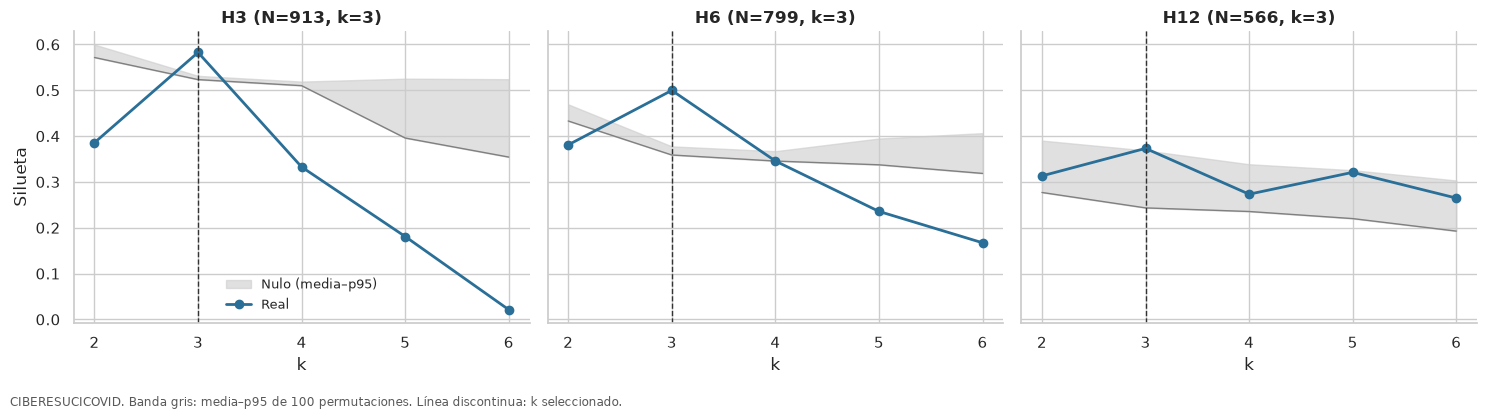

,Horizonte,k,silueta_real,nulo_media,nulo_p95,Ventaja frente al nulo,supera_p95,Elegido
0,H3,2,0.386,0.572,0.600,-0.186,False,False
1,H3,3,0.583,0.523,0.532,0.059,True,True
2,H3,4,0.333,0.510,0.519,-0.177,False,False
3,H3,5,0.181,0.396,0.525,-0.215,False,False
4,H3,6,0.021,0.354,0.524,-0.333,False,False
5,H6,2,0.381,0.433,0.469,-0.052,False,False
6,H6,3,0.500,0.359,0.378,0.141,True,True
7,H6,4,0.346,0.346,0.367,0.000,False,False
8,H6,5,0.236,0.337,0.395,-0.102,False,False
9,H6,6,0.167,0.319,0.406,-0.151,False,False


In [5]:
fig, axes = plt.subplots(
    1, len(HORIZONTES),
    figsize=(15, 4),
    sharey=True,
    squeeze=False
)
axes = axes.ravel()

tablas_k = []

for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]
    nl = r["nulo"].sort_values("k").copy()

    x = nl["k"].to_numpy(dtype=float)
    media = nl["nulo_media"].to_numpy(dtype=float)
    p95 = nl["nulo_p95"].to_numpy(dtype=float)
    real = nl["silueta_real"].to_numpy(dtype=float)

    ax.fill_between(
        x, media, p95,
        color="0.8", alpha=0.6,
        label="Nulo (media–p95)"
    )
    ax.plot(x, media, color="0.5", lw=1)
    ax.plot(
        x, real, "o-",
        color=COLOR[DESC], lw=2,
        label="Real"
    )
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)

    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})")
    ax.set_xticks(KS)
    ax.set_xlabel("k")

    nl["Horizonte"] = h
    nl["Ventaja frente al nulo"] = (
        nl["silueta_real"] - nl["nulo_media"]
    )
    nl["Elegido"] = nl["k"].eq(r["k"])
    tablas_k.append(nl)

axes[0].set_ylabel("Silueta")
axes[0].legend(frameon=False, fontsize=9)

nota(
    axes[0],
    f"{DESC}. Banda gris: media–p95 de "
    f"{FC['n_permutaciones']} permutaciones. "
    "Línea discontinua: k seleccionado."
)
plt.tight_layout()
guardar(fig, "03_eleccion_k")
plt.show()

comparacion_k = pd.concat(tablas_k, ignore_index=True)

display(
    comparacion_k[[
        "Horizonte", "k", "silueta_real",
        "nulo_media", "nulo_p95",
        "Ventaja frente al nulo", "supera_p95", "Elegido"
    ]].round(3)
)

comparacion_k.to_csv(TAB / "03_comparacion_k.csv", index=False)

El procedimiento selecciona tres grupos en los tres horizontes. La comparación con datos permutados respalda que existe estructura conjunta en las variables, y la separación es más marcada en el horizonte temprano.

Perfiles de reproducibilidad

In [6]:
perfiles = []

for h, r in resultados.items():
    t = r["desc"][r["cols"]].copy()
    t["Fenotipo"] = [nombre_f(c) for c in r["lab"]]

    for fenotipo, grupo in t.groupby("Fenotipo", sort=True):
        n = len(grupo)

        for variable in r["cols"]:
            s = grupo[variable].dropna()
            suficiente = n >= N_MIN and len(s) >= N_MIN

            perfiles.append({
                "Horizonte": h,
                "Fenotipo": fenotipo,
                "Variable": variable,
                "N grupo": n if n >= N_MIN else np.nan,
                "N con dato": len(s) if suficiente else np.nan,
                "Mediana": s.median() if suficiente else np.nan,
                "P25": s.quantile(0.25) if suficiente else np.nan,
                "P75": s.quantile(0.75) if suficiente else np.nan,
                "Cobertura (%)": (
                    100 * len(s) / n if suficiente else np.nan
                ),
            })

perfiles = pd.DataFrame(perfiles)

for h in HORIZONTES:
    print(f"\n{h}: medianas por fenotipo")
    display(
        perfiles.loc[perfiles["Horizonte"].eq(h)]
        .pivot(index="Variable", columns="Fenotipo", values="Mediana")
        .round(2)
    )

perfiles.to_csv(TAB / "03_perfiles_clinicos.csv", index=False)


H3: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_M3,79.2,69.65,67.0
fatiga_M3,0.0,1.00,0.0
fvc_M3,93.0,85.60,84.0
resolucion_M3,0.0,1.00,1.0



H6: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_M3,67.00,65.0,63.0
dlco_M6,78.00,71.0,70.0
dlco_cambio,5.90,4.5,4.5
fatiga_M3,0.00,1.0,0.0
fatiga_M6,0.00,1.0,0.0
fvc_M3,91.15,82.0,84.0
fvc_M6,93.00,88.0,87.0
fvc_cambio,3.00,6.0,5.8
resolucion_M3,1.00,1.0,1.0



H12: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_A1,78.0,76.0,74.0
dlco_M3,69.0,67.0,65.0
dlco_M6,71.5,68.0,67.0
dlco_cambio,8.0,2.1,6.0
fatiga_M3,0.0,1.0,0.0
fatiga_M6,0.0,1.0,0.0
fvc_A1,94.0,93.0,83.0
fvc_M3,90.0,85.6,79.5
fvc_M6,91.0,87.0,85.0


F1 mantiene una función pulmonar más favorable, F2 se distingue por la fatiga y F3 por una menor DLCO. Sin embargo, esta similitud entre horizontes no demuestra que los mismos pacientes permanezcan en cada grupo.

Y para las variables binarias


In [7]:
filas_validacion = []

for h, r in resultados.items():
    fila = {
        "Horizonte": h,
        "Jaccard bootstrap mínimo": (
            r["estab"]["jaccard_medio"].min()
        ),
        "ARI solo DLCO/FVC": r["ari_solo_compartidas"],
    }

    for cohorte, out in r["replicas"].items():
        etiqueta = ETQ.get(cohorte, cohorte)
        fila[f"ARI transferencia vs nativo: {etiqueta}"] = out["ari"]
        fila[f"IC95 inferior: {etiqueta}"] = out["ari_ic"][0]
        fila[f"IC95 superior: {etiqueta}"] = out["ari_ic"][1]

    filas_validacion.append(fila)

validacion = pd.DataFrame(filas_validacion).set_index("Horizonte")
display(validacion.round(3))
validacion.to_csv(TAB / "03_validacion_fenotipos.csv")

,Jaccard bootstrap mínimo,ARI solo DLCO/FVC,ARI transferencia vs nativo: POSTCOVID-Lleida,IC95 inferior: POSTCOVID-Lleida,IC95 superior: POSTCOVID-Lleida,ARI transferencia vs nativo: TENACITY,IC95 inferior: TENACITY,IC95 superior: TENACITY
Horizonte,,,,,,,,
H3,0.980,0.008,0.168,0.132,0.239,0.200,0.059,0.273
H6,0.998,0.004,0.239,0.051,0.304,0.293,0.047,0.386
H12,0.623,0.036,0.287,0.071,0.390,0.281,0.017,0.430


Los fenotipos presentan una elevada estabilidad interna en H3 y H6, con Jaccard mínimos de 0,980 y 0,998, pero menor estabilidad en H12, con 0,623. Su transferencia a Lleida y TENACITY muestra una concordancia limitada con los agrupamientos propios de esas cohortes, aunque los intervalos de confianza excluyen cero. Además, los ARI próximos a cero al utilizar solo DLCO y FVC indican que estas variables no bastan para recuperar los fenotipos originales: la estabilidad dentro de CIBERESUCICOVID no implica que los grupos sean directamente reproducibles en otras poblaciones.

Transiciones entre horizontes de tiempo de 3, 6 y 12 meses

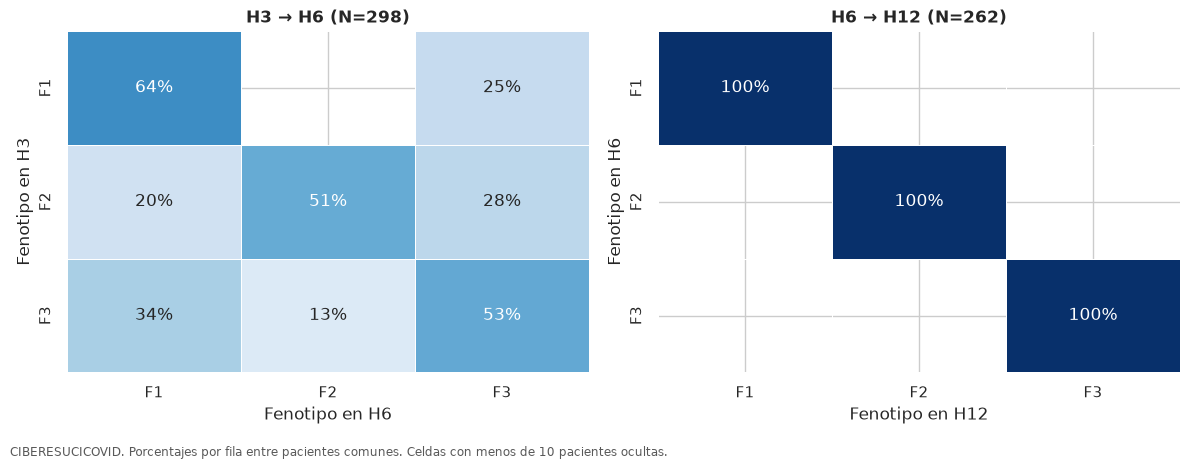

,N inicial,Pacientes comunes,% inicial con etiqueta posterior,ARI
Transición,,,,
H3 → H6,913,298,32.64,0.11
H6 → H12,799,262,32.79,1.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
filas = []
tablas_transicion = {}

for ax, (h1, h2) in zip(
    axes, [("H3", "H6"), ("H6", "H12")]
):
    r1, r2 = resultados[h1], resultados[h2]

    e1 = pd.Series(
        [nombre_f(c) for c in r1["lab"]],
        index=r1["desc"].index,
        name=h1
    )
    e2 = pd.Series(
        [nombre_f(c) for c in r2["lab"]],
        index=r2["desc"].index,
        name=h2
    )

    assert e1.index.is_unique and e2.index.is_unique

    tabla, ari, n = P.transiciones(e1, e2)

    filas.append({
        "Transición": f"{h1} → {h2}",
        "N inicial": len(e1),
        "Pacientes comunes": n,
        "% inicial con etiqueta posterior": (
            100 * n / len(e1) if len(e1) else np.nan
        ),
        "ARI": ari,
    })

    if n:
        tabla = tabla.reindex(
            index=[nombre_f(c) for c in range(r1["k"])],
            columns=[nombre_f(c) for c in range(r2["k"])],
            fill_value=0
        )

        denominador = tabla.sum(axis=1).replace(0, np.nan)
        pct = tabla.div(denominador, axis=0).mul(100)

        ocultar = tabla.lt(N_MIN) | pct.isna()
        anotaciones = pct.map(
            lambda v: "" if pd.isna(v) else f"{v:.0f}%"
        ).mask(ocultar, "")

        sns.heatmap(
            pct,
            mask=ocultar,
            annot=anotaciones.to_numpy(),
            fmt="",
            cmap="Blues",
            vmin=0, vmax=100,
            cbar=False,
            linewidths=0.5,
            ax=ax
        )

        tabla_publica = tabla.astype(float).mask(tabla < N_MIN)
        tablas_transicion[(h1, h2)] = tabla_publica
        tabla_publica.to_csv(
            TAB / f"03_transiciones_{h1}_{h2}_conteos.csv"
        )
    else:
        ax.text(
            0.5, 0.5, "Sin pacientes comunes",
            ha="center", va="center",
            transform=ax.transAxes
        )

    ax.set_xlabel(f"Fenotipo en {h2}")
    ax.set_ylabel(f"Fenotipo en {h1}")
    ax.set_title(f"{h1} → {h2} (N={n})")

nota(
    axes[0],
    f"{DESC}. Porcentajes por fila entre pacientes comunes. "
    f"Celdas con menos de {N_MIN} pacientes ocultas."
)
plt.tight_layout()
guardar(fig, "03_transiciones")
plt.show()

resumen_transiciones = pd.DataFrame(filas).set_index("Transición")
resumen_transiciones_publico = privacidad.suprimir_celdas(
    resumen_transiciones.round(2),
    N_MIN,
    ["N inicial", "Pacientes comunes"]
)

display(resumen_transiciones_publico)
resumen_transiciones_publico.to_csv(
    TAB / "03_resumen_transiciones.csv"
)

Entre H3 y H6, la concordancia de las agrupaciones es baja (ARI = 0,11), mientras que entre H6 y H12 es completa en los pacientes comunes (ARI = 1,00), lo que sugiere una mayor continuidad de la partición en los horizontes posteriores. Sin embargo, cada comparación incluye solo alrededor del 33% de los pacientes iniciales y los horizontes comparten información previa, por lo que no puede interpretarse como estabilidad clínica de toda la cohorte ni como capacidad predictiva demostrada.

En conjunto, identificamos tres perfiles estables en los horizontes tempranos de CIBERESUCICOVID, pero su limitada transferencia indica que no basta con trasladar los grupos originales utilizando solo las variables respiratorias. 

Esto justifica avanzar hacia fenotipado_comun, realizando el clustering conjuntamente en CIBERESUCICOVID, POSTCOVID-Lleida y TENACITY, utilizando las variables comparables entre las tres cohortes. Así buscamos perfiles comunes desde su definición, cuya estabilidad y reproducibilidad entre cohortes deberán validarse antes de utilizarlos para predecir la evolución a largo plazo.



### 2.2 Clusterización en todos los datasets

## 3. Modelo para clasificación de pacientes